In [1]:
# Random Forest Classifier

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

df = pd.read_csv('/content/student_performance.csv')
display(df.head())
print(df.info())

,StudyHours,Attendance,Resources,Extracurricular,Motivation,Internet,Gender,Age,LearningStyle,OnlineCourses,Discussions,AssignmentCompletion,ExamScore,EduTech,StressLevel,FinalGrade
0,19,64,1,0,0,1,0,19,2,8,1,59,40,0,1,3
1,19,64,1,0,0,1,0,23,3,16,0,90,66,0,1,2
2,19,64,1,0,0,1,0,28,1,19,0,67,99,1,1,0
3,19,64,1,1,0,1,0,19,2,8,1,59,40,0,1,3
4,19,64,1,1,0,1,0,23,3,16,0,90,66,0,1,2


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14003 entries, 0 to 14002
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   StudyHours            14003 non-null  int64
 1   Attendance            14003 non-null  int64
 2   Resources             14003 non-null  int64
 3   Extracurricular       14003 non-null  int64
 4   Motivation            14003 non-null  int64
 5   Internet              14003 non-null  int64
 6   Gender                14003 non-null  int64
 7   Age                   14003 non-null  int64
 8   LearningStyle         14003 non-null  int64
 9   OnlineCourses         14003 non-null  int64
 10  Discussions           14003 non-null  int64
 11  AssignmentCompletion  14003 non-null  int64
 12  ExamScore             14003 non-null  int64
 13  EduTech               14003 non-null  int64
 14  StressLevel           14003 non-null  int64
 15  FinalGrade            14003 non-null  int64
dtypes: i

In [3]:
le = LabelEncoder()
for col in df.select_dtypes(include=['object']).columns:
    df[col] = le.fit_transform(df[col])

target_col = 'FinalGrade'
X = df.drop(target_col, axis=1)
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [4]:
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_acc = accuracy_score(y_test, rf_pred)

svm_model = SVC(kernel='linear', random_state=42)
svm_model.fit(X_train, y_train)
svm_pred = svm_model.predict(X_test)
svm_acc = accuracy_score(y_test, svm_pred)

print(f'Random Forest Accuracy: {rf_acc:.4f}')
print(f'SVM Accuracy: {svm_acc:.4f}')

Random Forest Accuracy: 1.0000
SVM Accuracy: 0.9896


In [5]:
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_acc = accuracy_score(y_test, rf_pred)

svm_model = SVC(kernel='linear', random_state=42)
svm_model.fit(X_train, y_train)
svm_pred = svm_model.predict(X_test)
svm_acc = accuracy_score(y_test, svm_pred)

print(f'Random Forest Accuracy: {rf_acc:.4f}')
print(f'SVM Accuracy: {svm_acc:.4f}')

Random Forest Accuracy: 1.0000
SVM Accuracy: 0.9896


# Task 1


*   Comparative analysis: Random Forest VS SVM



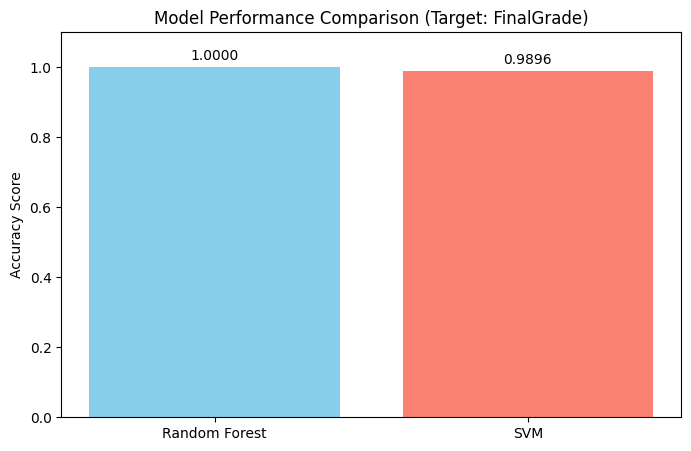

In [7]:
models = ['Random Forest', 'SVM']
accuracies = [rf_acc, svm_acc]

plt.figure(figsize=(8, 5))
plt.bar(models, accuracies, color=['skyblue', 'salmon'])
plt.ylabel('Accuracy Score')
plt.title('Model Performance Comparison (Target: FinalGrade)')
plt.ylim(0, 1.1)
for i, v in enumerate(accuracies):
    plt.text(i, v + 0.02, f'{v:.4f}', ha='center')
plt.show()

In [10]:
from sklearn.metrics import classification_report, f1_score, precision_score, recall_score

random_forest_report = classification_report(y_test, rf_pred, output_dict=True)
svm_report = classification_report(y_test, svm_pred, output_dict=True)

metrics_comparison = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Random Forest': [
        accuracy_score(y_test, rf_pred),
        precision_score(y_test, rf_pred, average='weighted'),
        recall_score(y_test, rf_pred, average='weighted'),
        f1_score(y_test, rf_pred, average='weighted')
    ],
    'SVM': [
        accuracy_score(y_test, svm_pred),
        precision_score(y_test, svm_pred, average='weighted'),
        recall_score(y_test, svm_pred, average='weighted'),
        f1_score(y_test, svm_pred, average='weighted')
    ]
})

display(metrics_comparison)

,Metric,Random Forest,SVM
0,Accuracy,1.0,0.989647
1,Precision,1.0,0.989732
2,Recall,1.0,0.989647
3,F1-Score,1.0,0.989656


Random Forest is thus a better model in this scenario.

# Task 2

* interpretation and recommendations

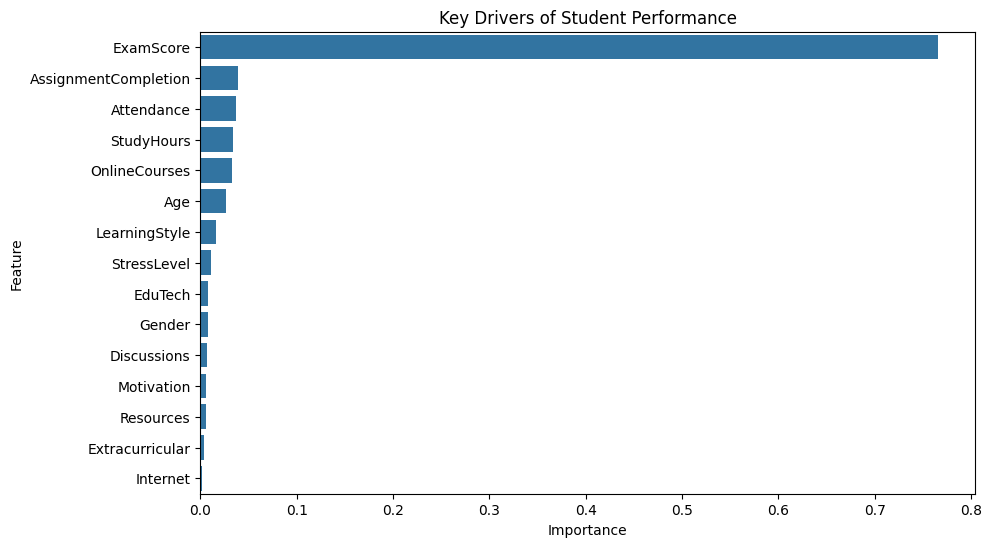

In [9]:
import numpy as np

importances = rf_model.feature_importances_
feature_names = df.drop('FinalGrade', axis=1).columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
plt.title('Key Drivers of Student Performance')
plt.show()

**Targeted Interventions:** Since Study Hours and Attendance are primary metrics of success, the platform should implement automated nudges for students whose activity levels drop below a specific threshold.

**Learning Paths:** Use the model to identify students at risk of low 'FinalGrade' early in the semester and provide them with supplementary 'Resources' or 'EduTech' tools tailored to their 'LearningStyle'.

**Engagement Enhancement:** For learners with low 'Motivation' or 'AssignmentCompletion', introduce gamification elements or peer-led 'Discussions' to foster a sense of community and accountability.

**Course Recommendations:** Recommend advanced courses to high-performing students (predicted high final gradee) and foundational skill-building modules to those predicted to struggle, ensuring the content matches their current performance trajectory./